# Config B — PPO (Proximal Policy Optimization)

**Author:** Mehmet Karaca  
**Environment:** ICU-Sepsis-v2 with 47-dim continuous observations  
**Algorithm:** Proximal Policy Optimization (PPO) via Stable-Baselines3

### Clinical failure wrappers active by default
| Wrapper | Effect | Probability |
|---------|--------|-------------|
| `EpisodicNoisyObsEnv` | Gaussian noise on all observations | 15% of episodes |
| `EpisodicMissingObsEnv` | 4 lab features zeroed out | 15% of episodes |
| `AcuteEventEnv` | Sudden patient death (irreducible) | 1% per step |

**Random baseline to beat:** 65.6% survival rate, mean return 0.5624

## 0. Setup

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from envs.wrappers import make_clinical_env
from agents.config_b.ppo import PPOConfig, train_ppo, load_ppo, get_policy
from utils.evaluation import eval_agent, print_results

sns.set_theme(style='whitegrid', palette='tab10')
SEED = 42
np.random.seed(SEED)

print('Setup complete.')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Setup complete.


## 1. Random Baseline
Establishing the lower bound before any learning.

In [3]:
env = make_clinical_env()
random_policy = lambda obs: env.action_space.sample()

random_results = eval_agent(random_policy, make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('Random Baseline (Config B)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config B) ===
  Mean return  : 0.5737 ± 0.4746
  Survival rate: 66.8%
  Mean ep len  : 9.5


## 2. PPO — Hyperparameter Justification

| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| `learning_rate` | 3e-4 | Standard Adam LR for PPO; stable for small networks |
| `n_steps` | 1024 | ~100 full episodes per update — stable gradient estimate |
| `batch_size` | 64 | Small enough for variance reduction, large enough to be efficient |
| `n_epochs` | 10 | Multiple passes over each batch; clipping prevents over-fitting |
| `gamma` | 1.0 | Undiscounted returns — matches env convention |
| `gae_lambda` | 0.95 | Standard GAE smoothing; balances bias vs variance in advantage estimates |
| `clip_range` | 0.2 | Standard PPO clip; prevents destructive policy updates |
| `ent_coef` | 0.01 | Small entropy bonus to maintain exploration across 25 actions |
| `net_arch` | [64, 64] | Sufficient capacity for 47-dim input without overfitting |

## 3. Training

In [4]:
cfg = PPOConfig(
    total_timesteps=500_000,
    seed=SEED,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    net_arch=[64, 64],
)

print('Training PPO for', cfg.total_timesteps, 'timesteps...')
model, callback = train_ppo(make_clinical_env, cfg=cfg, save_path='results/config_b/ppo_model')
print('Training complete.')

Training PPO for 500000 timesteps...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Model saved to results/config_b/ppo_model.zip
Training complete.


## 4. Training Curve

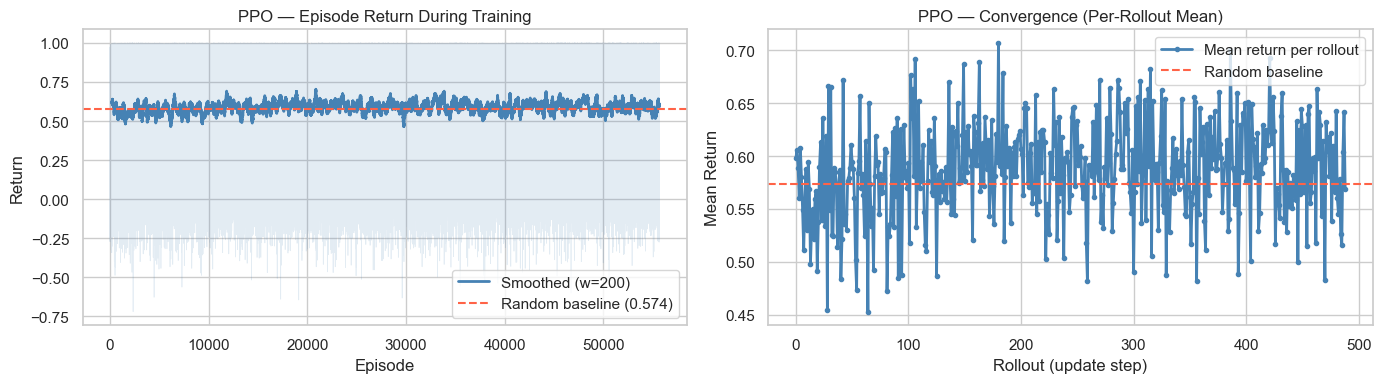

Plot saved to plots/configB_ppo_training_curve.png


In [5]:
episode_returns = np.array(callback.episode_returns)
rollout_means   = np.array(callback.rollout_means)

window = 200
smoothed = np.convolve(episode_returns, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-episode return
ax = axes[0]
ax.plot(episode_returns, alpha=0.15, color='steelblue', linewidth=0.5)
ax.plot(np.arange(window-1, len(episode_returns)), smoothed,
        color='steelblue', linewidth=2, label=f'Smoothed (w={window})')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.5, label=f"Random baseline ({random_results['mean_return']:.3f})")
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('PPO — Episode Return During Training')
ax.legend()

# Right: per-rollout mean return (cleaner convergence view)
ax = axes[1]
ax.plot(rollout_means, color='steelblue', linewidth=2, marker='o',
        markersize=3, label='Mean return per rollout')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.5, label='Random baseline')
ax.set_xlabel('Rollout (update step)')
ax.set_ylabel('Mean Return')
ax.set_title('PPO — Convergence (Per-Rollout Mean)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_training_curve.png', dpi=150)
plt.show()
print('Plot saved to plots/configB_ppo_training_curve.png')

## 5. Evaluation (Fixed Protocol)
Using the shared `eval_agent()` with `n_eval_episodes=1000, seed=42`.

In [6]:
ppo_results = eval_agent(get_policy(model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('PPO (Config B)', ppo_results)

improvement = ppo_results['survival_rate'] - random_results['survival_rate']
print(f"\n  Survival improvement over random: +{improvement:.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== PPO (Config B) ===
  Mean return  : 0.6098 ± 0.4715
  Survival rate: 66.3%
  Mean ep len  : 8.8

  Survival improvement over random: +-0.5%


## 6. Return Distribution

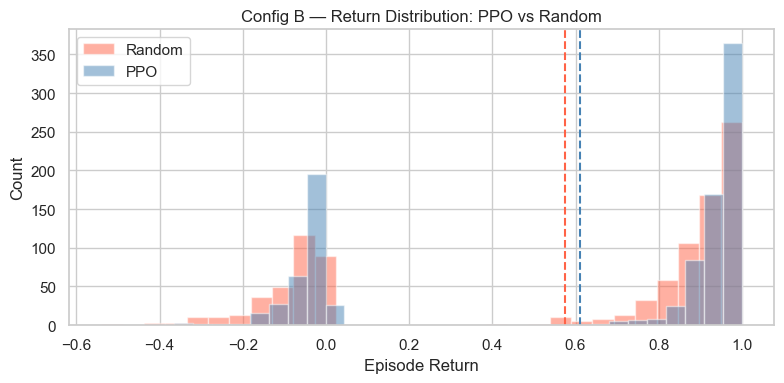

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(random_results['returns'], bins=30, alpha=0.5, color='tomato', label='Random')
ax.hist(ppo_results['returns'],    bins=30, alpha=0.5, color='steelblue', label='PPO')
ax.axvline(random_results['mean_return'], color='tomato',   linestyle='--', linewidth=1.5)
ax.axvline(ppo_results['mean_return'],    color='steelblue', linestyle='--', linewidth=1.5)
ax.set_xlabel('Episode Return')
ax.set_ylabel('Count')
ax.set_title('Config B — Return Distribution: PPO vs Random')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_return_distribution.png', dpi=150)
plt.show()

## 7. Clinical Wrapper Sensitivity Analysis

Isolating how each failure mode affects the trained PPO policy.
We evaluate on the **same trained model** but with different wrapper configurations.

In [10]:
from envs.wrappers import make_clinical_env

wrapper_configs = {
    'No wrappers\n(clean env)':    dict(malfunction_prob=0.0, missing_prob=0.0, event_prob=0.0),
    'Noisy obs only':               dict(malfunction_prob=0.15, missing_prob=0.0, event_prob=0.0),
    'Missing obs only':             dict(malfunction_prob=0.0, missing_prob=0.15, event_prob=0.0),
    'Acute events only':            dict(malfunction_prob=0.0, missing_prob=0.0, event_prob=0.01),
    'All wrappers\n(default)':     dict(malfunction_prob=0.15, missing_prob=0.15, event_prob=0.01),
}

sensitivity_results = {}
for label, kwargs in wrapper_configs.items():
    factory = lambda kw=kwargs: make_clinical_env(**kw)
    res = eval_agent(get_policy(model), factory, n_eval_episodes=1000, seed=SEED)
    sensitivity_results[label] = res
    print(f"{label.replace(chr(10), ' '):30s}  survival={res['survival_rate']:.1%}  return={res['mean_return']:.4f}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
No wrappers (clean env)         survival=72.4%  return=0.6656
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Noisy obs only                  survival=72.6%  return=0.6674
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Missing obs only                survival=72.6%  return=0.6683
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Acute events only               survival=66.5%  return=0.6113
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
All wrappers (default)          survival=66.4%  return=0.6105


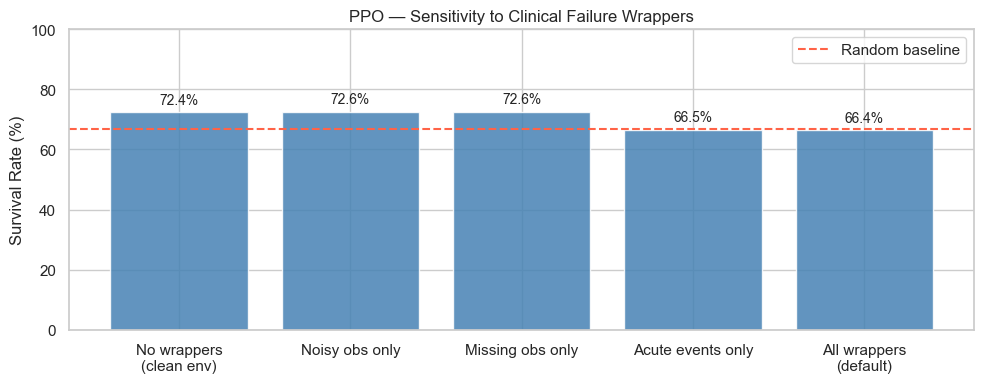

In [11]:
labels  = list(sensitivity_results.keys())
survivals = [sensitivity_results[k]['survival_rate'] * 100 for k in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, survivals, color='steelblue', alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.axhline(random_results['survival_rate'] * 100, color='tomato', linestyle='--',
           linewidth=1.5, label='Random baseline')
ax.set_ylabel('Survival Rate (%)')
ax.set_title('PPO — Sensitivity to Clinical Failure Wrappers')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_wrapper_sensitivity.png', dpi=150)
plt.show()

## 8. Summary Table

In [12]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Agent':         'Random Baseline',
        'Mean Return':   f"{random_results['mean_return']:.4f}",
        'Std Return':    f"{random_results['std_return']:.4f}",
        'Survival Rate': f"{random_results['survival_rate']:.1%}",
        'Mean Ep Len':   f"{random_results['mean_ep_length']:.1f}",
    },
    {
        'Agent':         'PPO (ours)',
        'Mean Return':   f"{ppo_results['mean_return']:.4f}",
        'Std Return':    f"{ppo_results['std_return']:.4f}",
        'Survival Rate': f"{ppo_results['survival_rate']:.1%}",
        'Mean Ep Len':   f"{ppo_results['mean_ep_length']:.1f}",
    },
])

print(summary.to_string(index=False))

          Agent Mean Return Std Return Survival Rate Mean Ep Len
Random Baseline      0.5737     0.4746         66.8%         9.5
     PPO (ours)      0.6098     0.4715         66.3%         8.8


## 9. Loading a Saved Model (Reproducibility)

Any team member can skip training and load the saved model:

In [13]:
# loaded_model = load_ppo('results/config_b/ppo_model')
# loaded_results = eval_agent(get_policy(loaded_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
# print_results('PPO (loaded)', loaded_results)